In [26]:
from pathlib import Path
import pandas as pd
import numpy as np


DATA_DIR = Path(
    r"C:\Python\CSUREMM\data_primitive"
)


gt_diff = pd.read_csv(
    DATA_DIR / "gt_diff_panel.csv",
    parse_dates=["Time"]
).set_index("Time")


gt_logdiff = pd.read_csv(
    DATA_DIR / "gt_log_diff_panel.csv",
    parse_dates=["Time"]
).set_index("Time")


stationarity = pd.read_csv(
    DATA_DIR / "stationarity_summary.csv"
)


sp500 = pd.read_csv(
    DATA_DIR / "sp500_daily.csv",
    parse_dates=["date"]
).set_index("date")

In [2]:
def gt_eda_summary(panel):

    rows = []

    for col in panel.columns:

        x = panel[col]

        rows.append({

            "term": col,

            "observations":
                x.notna().sum(),

            "missing":
                x.isna().sum(),

            "mean":
                x.mean(),

            "std":
                x.std(),

            "min":
                x.min(),

            "max":
                x.max(),

            "zero_share":
                (x == 0).mean(),

            "unique_values":
                x.nunique(),

            "abs_change_mean":
                x.abs().mean(),

            "abs_change_std":
                x.abs().std()

        })


    return (
        pd.DataFrame(rows)
        .sort_values(
            "std",
            ascending=False
        )
    )


eda = gt_eda_summary(
    gt_logdiff
)


eda.to_csv(
    DATA_DIR / "eda_summary.csv",
    index=False
)


print(
    eda.head(20)
)

             term  observations  missing          mean       std       min  \
131      squander          1611        0  3.307927e-18  3.096515 -6.447306   
22       bequeath          1611        0 -2.713446e-03  2.981310 -6.366470   
24      betrothal          1611        0  0.000000e+00  2.429366 -6.366470   
2       affluence          1611        0  2.348328e-03  2.422803 -5.755742   
96       nobleman          1611        0  2.637816e-04  2.275759 -5.247024   
92    meritorious          1611        0  2.714677e-03  2.220432 -5.646624   
143  unprofitable          1611        0  1.102642e-18  2.099245 -6.413459   
4          afloat          1611        0  3.021581e-04  1.949352 -5.371185   
88      liquidate          1611        0  2.383895e-03  1.778331 -5.469548   
124      richness          1611        0  4.012135e-04  1.692590 -4.892019   
54      destitute          1611        0 -5.898476e-05  1.567058 -4.958944   
8    aristocratic          1611        0  2.171385e-03  1.543731

In [3]:
corr = (
    gt_logdiff
    .corr()
)


corr.to_csv(
    DATA_DIR / "corr_matrix.csv"
)


print(
    corr.iloc[:10,:10]
)

                accrue  advantage  affluence  affluent    afloat  allowance  \
accrue        1.000000   0.690533   0.270753  0.336467  0.171432   0.550716   
advantage     0.690533   1.000000   0.353016  0.502309  0.239729   0.755997   
affluence     0.270753   0.353016   1.000000  0.271722  0.159937   0.333974   
affluent      0.336467   0.502309   0.271722  1.000000  0.116125   0.456373   
afloat        0.171432   0.239729   0.159937  0.116125  1.000000   0.208211   
allowance     0.550716   0.755997   0.333974  0.456373  0.208211   1.000000   
aristocracy   0.401703   0.463856   0.235625  0.296572  0.203201   0.403888   
aristocrat    0.192176   0.288323   0.123998  0.181889  0.127261   0.260926   
aristocratic  0.188793   0.254977   0.148025  0.175292  0.055280   0.194755   
associate     0.698664   0.918880   0.356604  0.497372  0.234860   0.773968   

              aristocracy  aristocrat  aristocratic  associate  
accrue           0.401703    0.192176      0.188793   0.698664  


In [4]:
def high_corr_pairs(
    corr,
    threshold=0.8
):

    pairs=[]

    cols = corr.columns


    for i in range(len(cols)):

        for j in range(i+1,len(cols)):

            value = corr.iloc[i,j]

            if abs(value) >= threshold:

                pairs.append({

                    "term1":cols[i],

                    "term2":cols[j],

                    "correlation":value

                })


    return (
        pd.DataFrame(pairs)
        .sort_values(
            "correlation",
            key=lambda x:x.abs(),
            ascending=False
        )
    )


corr_pairs = high_corr_pairs(
    corr,
    0.8
)


corr_pairs.to_csv(
    DATA_DIR / "corr_high_pairs.csv",
    index=False
)


print(
    corr_pairs.head(20)
)

            term1         term2  correlation
208    contribute    successful     0.942629
155     community   cooperative     0.935522
34      associate     community     0.932570
6       advantage     community     0.932538
182  compensation   partnership     0.932338
163     community   partnership     0.930445
251       default   partnership     0.930026
46      associate   partnership     0.928346
229   cooperative   partnership     0.925440
35      associate  compensation     0.923936
174  compensation   cooperative     0.922704
152     community  compensation     0.922377
30      associate   beneficiary     0.921875
178  compensation        equity     0.921644
76    beneficiary     community     0.918984
154     community  contribution     0.918883
0       advantage     associate     0.918880
213  contribution       expense     0.917737
38      associate   cooperative     0.914800
97        benefit    contribute     0.914756


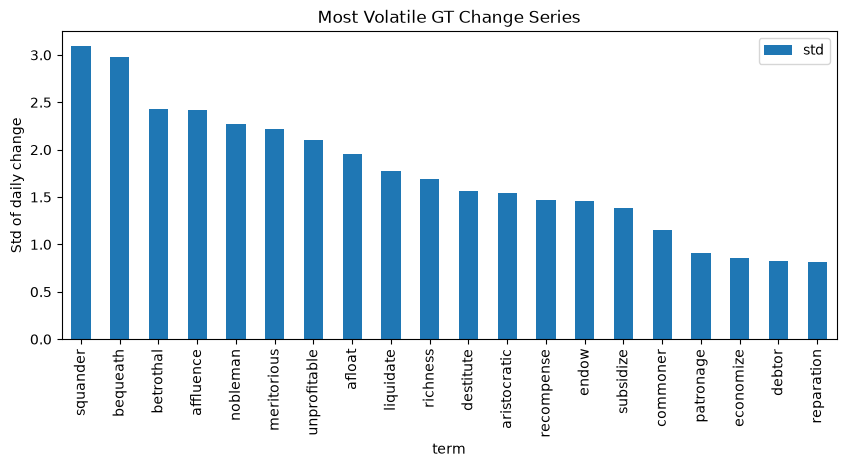

In [6]:
import matplotlib.pyplot as plt

eda.head(20).plot(
    x="term",
    y="std",
    kind="bar",
    figsize=(10,4),
    title="Most Volatile GT Change Series"
)

plt.ylabel(
    "Std of daily change"
)

plt.show()

Question: Are there latent dimensions in search behavior that correspond to Fear and Greed?

In [8]:
# Standardize the data for factor analysis

from sklearn.preprocessing import StandardScaler

X = gt_logdiff.copy()

# remove columns with too many missing values
valid_cols = (
    X.isna()
    .mean()
    .loc[lambda x: x < 0.10]
    .index
)

X = X[valid_cols]

# simple imputation
X = X.fillna(0)

scaler = StandardScaler()

X_std = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

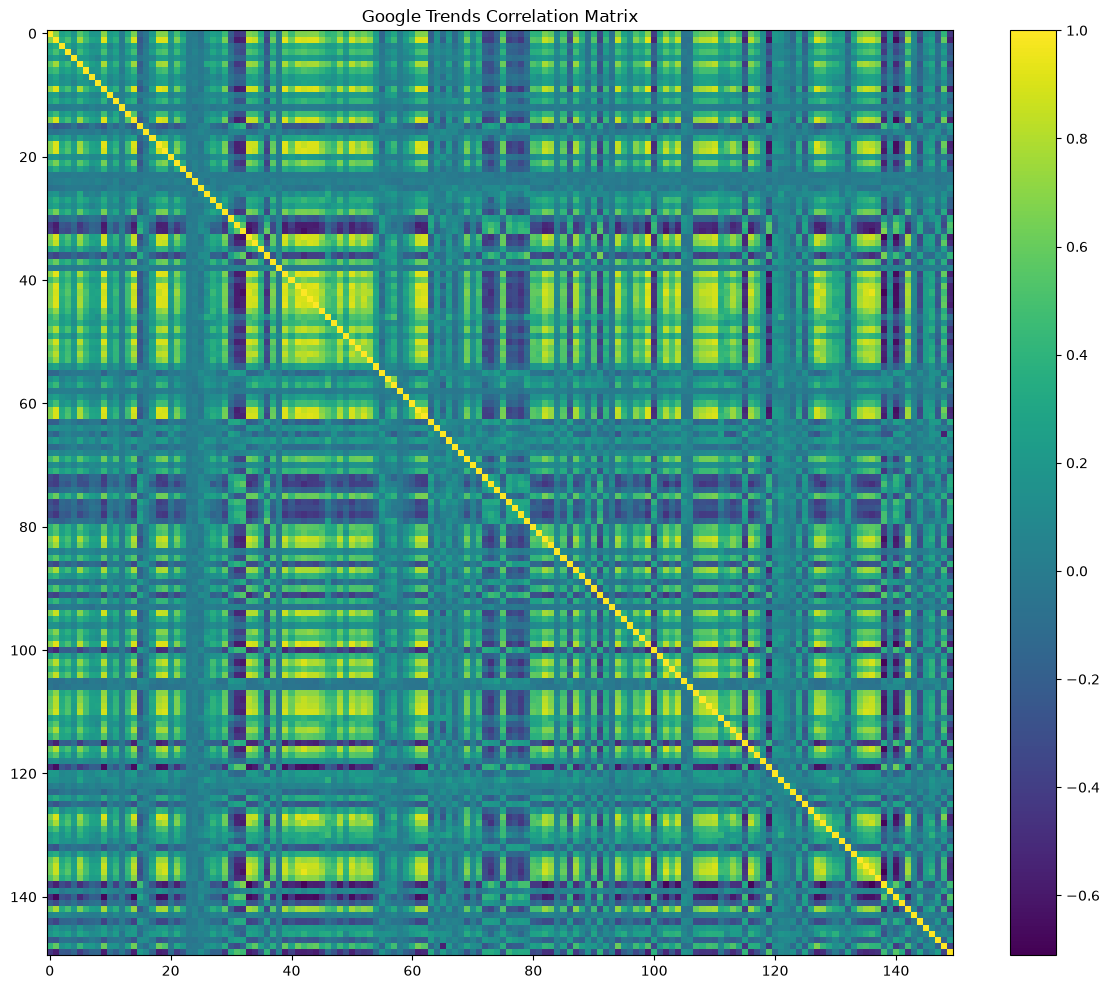

In [9]:
# Correlation heatmap
import matplotlib.pyplot as plt

corr = X_std.corr()

plt.figure(figsize=(12,10))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.title(
    "Google Trends Correlation Matrix"
)

plt.tight_layout()

plt.show()

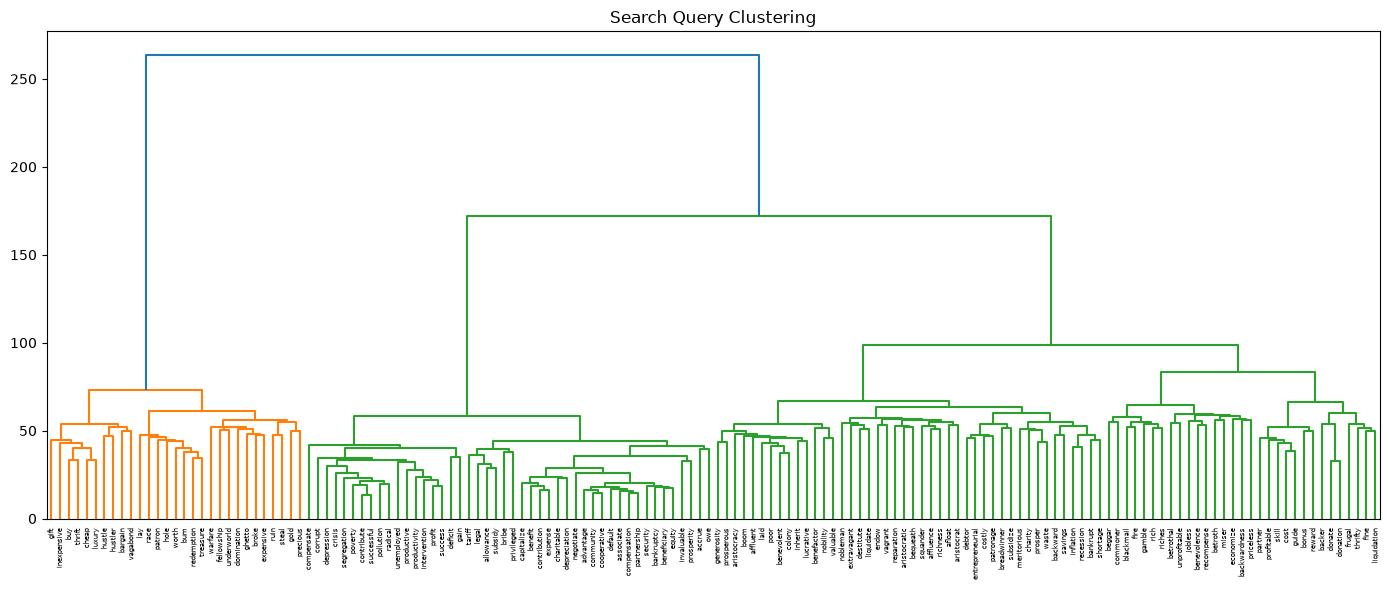

In [10]:
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram

Z = linkage(
    X_std.T,
    method="ward"
)

plt.figure(figsize=(14,6))

dendrogram(
    Z,
    labels=X_std.columns,
    leaf_rotation=90
)

plt.title(
    "Search Query Clustering"
)

plt.tight_layout()

plt.show()

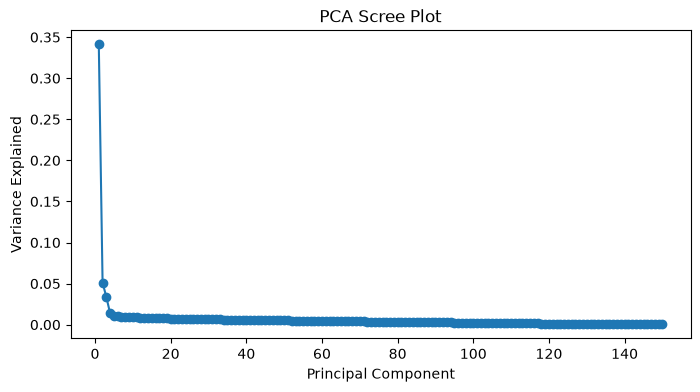

In [11]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(X_std)

explained = pca.explained_variance_ratio_

plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(explained)+1),
    explained,
    marker="o"
)

plt.xlabel(
    "Principal Component"
)

plt.ylabel(
    "Variance Explained"
)

plt.title(
    "PCA Scree Plot"
)

plt.show()

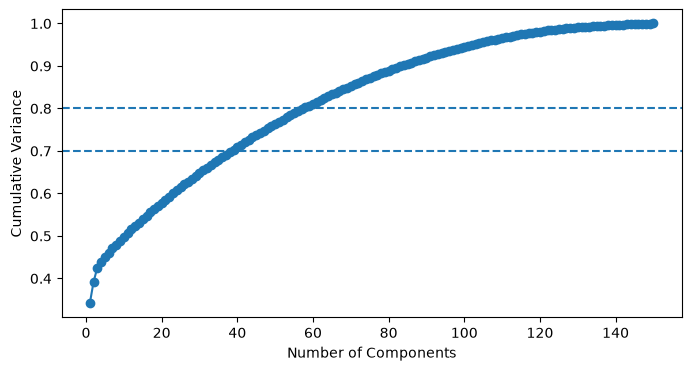

In [12]:
cum_var = np.cumsum(explained)

plt.figure(figsize=(8,4))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker="o"
)

plt.axhline(
    0.70,
    linestyle="--"
)

plt.axhline(
    0.80,
    linestyle="--"
)

plt.ylabel(
    "Cumulative Variance"
)

plt.xlabel(
    "Number of Components"
)

plt.show()

In [13]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_std.columns,
    columns=[
        f"PC{i+1}"
        for i in range(len(X_std.columns))
    ]
)

loadings.to_csv(
    DATA_DIR / "pca_loadings.csv"
)

for pc in ["PC1","PC2","PC3"]:

    print("\n", pc)

    print(
        loadings[pc]
        .sort_values()
        .tail(15)
    )

    print(
        loadings[pc]
        .sort_values()
        .head(15)
    )


 PC1
success         0.128553
successful      0.130389
capitalize      0.130673
contribution    0.130707
default         0.130798
expense         0.130927
cooperative     0.131076
profit          0.131167
compensation    0.131219
associate       0.131255
advantage       0.131442
benefit         0.132445
community       0.132707
partnership     0.133545
contribute      0.134202
Name: PC1, dtype: float64
treasure     -0.097488
thrift       -0.094377
redemption   -0.094252
buy          -0.087463
bum          -0.085456
worth        -0.079927
race         -0.074545
patron       -0.071712
hustler      -0.066654
gift         -0.066193
cheap        -0.063455
luxury       -0.062220
hole         -0.056780
ghetto       -0.055199
vagabond     -0.054000
Name: PC1, dtype: float64

 PC2
donate         0.151697
donation       0.151865
lay            0.152214
bum            0.152732
fine           0.160061
broke          0.162830
expensive      0.177394
cheap          0.180518
gold           0.180689


In [ ]:
from sklearn.decomposition import FactorAnalysis

fa = FactorAnalysis(
    n_components=3,
    random_state=42,
    rotation="varimax" #added this to make the results more interpretable
)

scores = fa.fit_transform(X_std)

loadings = pd.DataFrame(
    fa.components_.T,
    index=X_std.columns,
    columns=[
        "Factor1",
        "Factor2",
        "Factor3"
    ]
)

print(loadings)

loadings.to_csv("factor_loadings.csv")

            Factor1   Factor2   Factor3
accrue     0.706732 -0.009530  0.095742
advantage  0.947690 -0.006075  0.111168
affluence  0.389209 -0.116021 -0.103056
affluent   0.551309 -0.048596 -0.163128
afloat     0.266691 -0.014223 -0.061298
...             ...       ...       ...
vagrant    0.255317 -0.005696 -0.074490
valuable   0.344816  0.037662 -0.470458
warfare   -0.230899  0.124331 -0.297063
waste      0.569468  0.322655  0.362945
worth     -0.548613  0.304064 -0.299264

[150 rows x 3 columns]


In [34]:
# 1. Calculate the sum of squares of loadings for each factor
ss_loadings = (loadings ** 2).sum()

# 2. Proportion of variance explained by each factor
variance_explained = ss_loadings / len(X_std.columns)

# 3. Print the explained variance ratio and cumulative variance
print("Variance Explained by Each Factor:")
print(variance_explained)
print("\nCumulative Variance Explained:")
print(variance_explained.cumsum())

Variance Explained by Each Factor:
Factor1    0.336311
Factor2    0.043042
Factor3    0.035577
dtype: float64

Cumulative Variance Explained:
Factor1    0.336311
Factor2    0.379353
Factor3    0.414930
dtype: float64


In [29]:
for factor in loadings.columns:

    print("\n" + "=" * 60)
    print(factor)
    print("=" * 60)

    print("\nMost Positive")

    print(
        loadings[factor]
        .sort_values(ascending=False)
        .head(20)
    )

    print("\nMost Negative")

    print(
        loadings[factor]
        .sort_values()
        .head(20)
    )


Factor1

Most Positive
community       0.957905
partnership     0.957621
benefit         0.950303
compensation    0.950287
associate       0.948290
advantage       0.947690
contribute      0.947568
expense         0.947094
cooperative     0.943691
profit          0.942826
contribution    0.942079
default         0.939678
equity          0.934482
beneficiary     0.930889
capitalize      0.925646
bankruptcy      0.922673
security        0.918983
success         0.918560
successful      0.917761
poverty         0.912726
Name: Factor1, dtype: float64

Most Negative
treasure     -0.673933
redemption   -0.649477
thrift       -0.622463
buy          -0.580675
bum          -0.578489
worth        -0.548613
race         -0.534205
patron       -0.501914
hustler      -0.444277
gift         -0.430235
cheap        -0.392732
luxury       -0.389256
ghetto       -0.384037
hole         -0.373494
vagabond     -0.363538
lay          -0.309363
hustle       -0.308973
underworld   -0.276667
bargain      -0.2

In [33]:
# Create factor scores DataFrame

factor_scores = pd.DataFrame(
    scores,
    index=X_std.index,
    columns=[
        "Factor1",
        "Factor2",
        "Factor3"
    ]
)

factor_scores

,Factor1,Factor2,Factor3
Time,,,
2022-01-02,0.439294,0.697160,-1.143778
2022-01-03,0.085540,-0.811563,1.108541
2022-01-04,1.146483,2.162181,-2.225281
2022-01-05,-0.205586,-0.754178,0.326958
2022-01-06,-1.158643,-4.425895,2.413040
...,...,...,...
2026-05-27,0.197479,0.571040,0.476888
2026-05-28,0.201478,0.674566,-0.648154
2026-05-29,-0.356899,-0.308402,0.190454


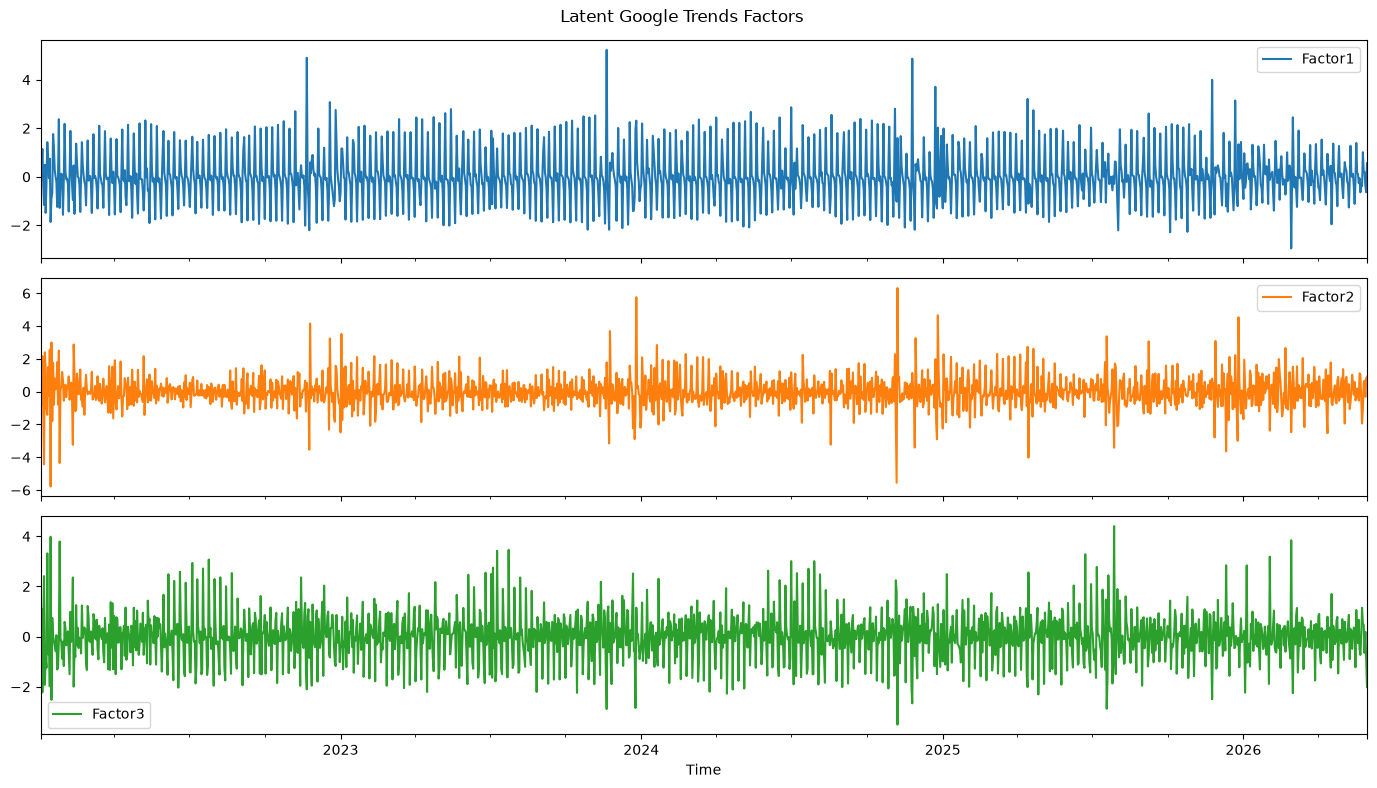

In [31]:
import matplotlib.pyplot as plt

factor_scores.plot(
    figsize=(14,8),
    subplots=True,
    title="Latent Google Trends Factors"
)

plt.tight_layout()

plt.show()

In [20]:
factor_z = (
    factor_scores
    - factor_scores.mean()
) / factor_scores.std()

factor_corr = factor_z.corr()

print(
    factor_corr.round(3)
)

         Factor1  Factor2  Factor3
Factor1      1.0     -0.0     -0.0
Factor2     -0.0      1.0      0.0
Factor3     -0.0      0.0      1.0


The Google Trends universe contains one dominant common
attention factor explaining approximately 34% of total variation.

Additional factors exist but are much weaker and appear
to reflect heterogeneous themes such as consumer spending,
social cooperation, and economic distress.

A clean Fear-Greed decomposition has not yet emerged.